In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jtiptj/chest-xray-pneumoniacovid19tuberculosis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumoniacovid19tuberculosis' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumoniacovid19tuberculosis


Using device: cpu
Classes: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']

Epoch 1/5
--------------------
Train Loss: 0.2262, Train Acc: 91.50%
Val Loss: 0.2361, Val Acc: 84.21%

Epoch 2/5
--------------------
Train Loss: 0.1097, Train Acc: 96.17%
Val Loss: 0.3817, Val Acc: 92.11%

Epoch 3/5
--------------------
Train Loss: 0.0678, Train Acc: 97.91%
Val Loss: 0.2329, Val Acc: 94.74%

Epoch 4/5
--------------------
Train Loss: 0.0390, Train Acc: 98.66%
Val Loss: 0.1494, Val Acc: 97.37%

Epoch 5/5
--------------------
Train Loss: 0.0251, Train Acc: 99.26%
Val Loss: 0.0935, Val Acc: 97.37%


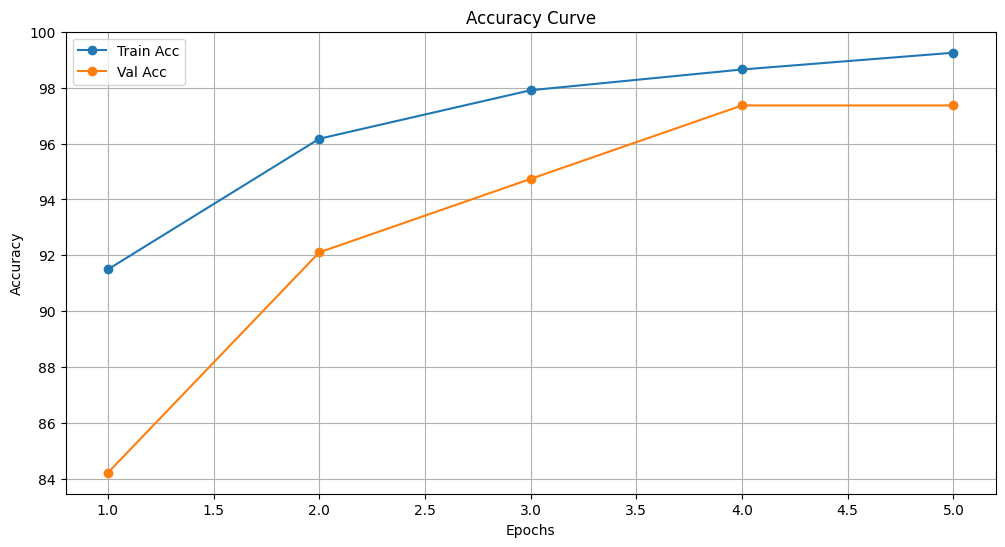

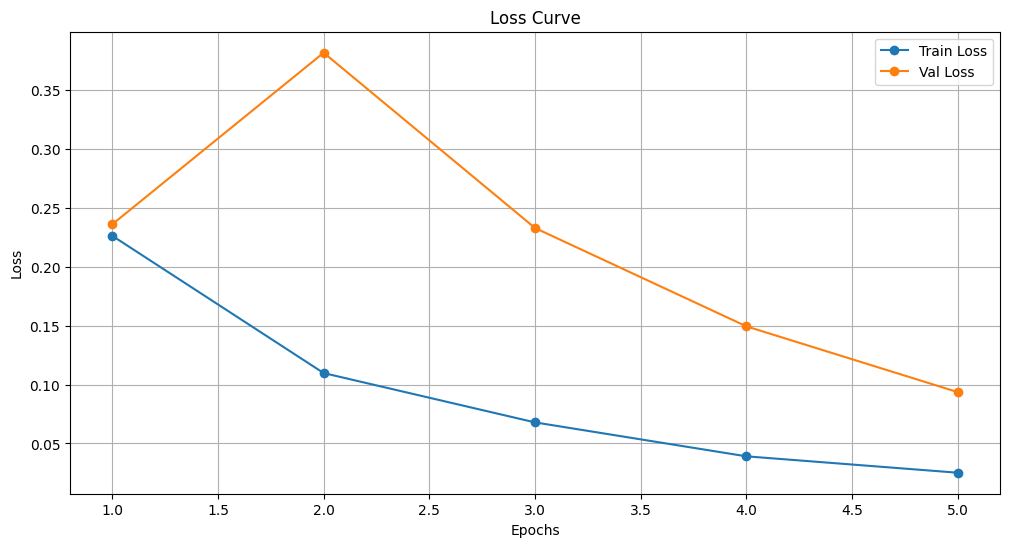


Testing the model...
Test Loss: 0.4085, Test Acc: 90.92%


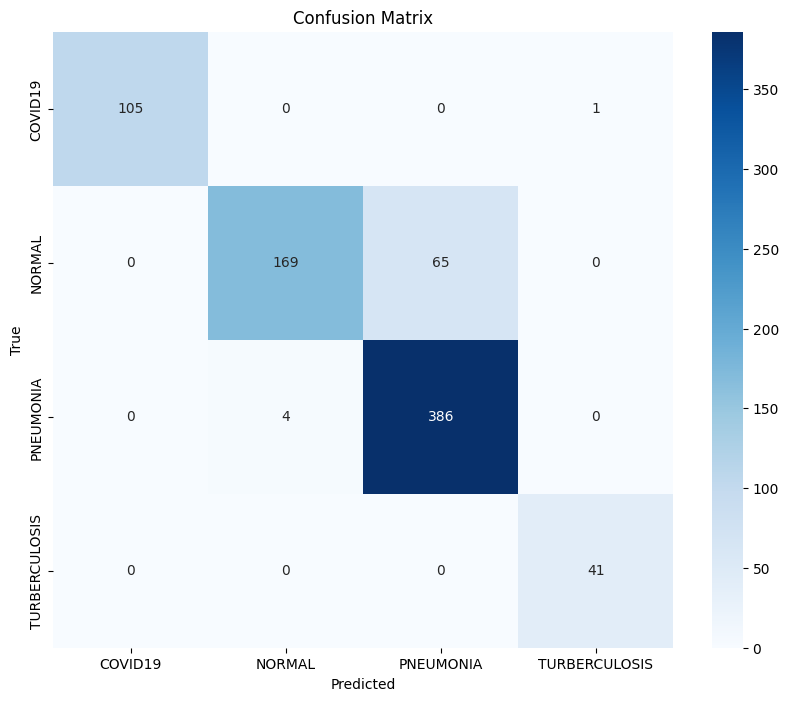


Classification Report:
               precision    recall  f1-score   support

      COVID19       1.00      0.99      1.00       106
       NORMAL       0.98      0.72      0.83       234
    PNEUMONIA       0.86      0.99      0.92       390
TURBERCULOSIS       0.98      1.00      0.99        41

     accuracy                           0.91       771
    macro avg       0.95      0.93      0.93       771
 weighted avg       0.92      0.91      0.91       771



In [15]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# Data Augmentation
# ===============================
train_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.RandomCrop(height=240, width=240),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(height=240, width=240),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# ===============================
# Albumentations Dataset Wrapper
# ===============================
class AlbumentationsDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = np.array(img)
        img = self.transform(image=img)["image"]
        return img, label

# ===============================
# Dataset Paths (CHANGE IF NEEDED)
# ===============================
data_dir = r"/kaggle/input/chest-xray-pneumoniacovid19tuberculosis"
train_dir = f"{data_dir}/train"
val_dir = f"{data_dir}/val"
test_dir = f"{data_dir}/test"

# ===============================
# Load Datasets
# ===============================
train_dataset = AlbumentationsDataset(datasets.ImageFolder(train_dir), train_transform)
val_dataset = AlbumentationsDataset(datasets.ImageFolder(val_dir), val_test_transform)
test_dataset = AlbumentationsDataset(datasets.ImageFolder(test_dir), val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.dataset.classes)

# ===============================
# Model (EfficientNet-B1)
# ===============================
model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(train_dataset.dataset.classes))
)
model = model.to(device)

# ===============================
# Loss, Optimizer, Scheduler
# ===============================
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-6)  # changed T_max to 5

# ===============================
# Training Loop
# ===============================
epochs = 5   # changed from 10 to 5
train_acc_history, val_acc_history = [], []
train_loss_history, val_loss_history = [], []
learning_rates = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-" * 20)

    # ---- Training ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # ---- Validation ----
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100. * correct / total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Save learning rate
    learning_rates.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

# ===============================
# Plot Training Curves
# ===============================
def plot_metrics(train_acc, val_acc, train_loss, val_loss, epochs):
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, epochs + 1), train_acc, label='Train Acc', marker='o')
    plt.plot(range(1, epochs + 1), val_acc, label='Val Acc', marker='o')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy Curve')
    plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(range(1, epochs + 1), train_loss, label='Train Loss', marker='o')
    plt.plot(range(1, epochs + 1), val_loss, label='Val Loss', marker='o')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss Curve')
    plt.legend(); plt.grid(True); plt.show()

plot_metrics(train_acc_history, val_acc_history, train_loss_history, val_loss_history, epochs)

# ===============================
# Testing Phase
# ===============================
print("\nTesting the model...")
model.eval()
test_loss, correct, total = 0.0, 0, 0
all_labels, all_predictions, all_confidences = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        confidences = torch.softmax(outputs, dim=1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())

test_loss = test_loss / len(test_loader.dataset)
test_acc = 100. * correct / total
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

# ===============================
# Confusion Matrix
# ===============================
conf_matrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.dataset.classes,
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ===============================
# Classification Report
# ===============================
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=test_dataset.dataset.classes))



In [14]:
import numpy as np

# Convert predictions & labels to numpy arrays if they are tensors
labels = np.array(all_labels)
preds = np.array(all_predictions)

# Get all unique classes
classes = test_dataset.dataset.classes

# Loop through each class and show 3 samples
for class_idx, class_name in enumerate(classes):
    print(f"\n=== Showing samples for class: {class_name} ===")

    # Find indices where the true label == class
    class_indices = np.where(labels == class_idx)[0]

    # Pick up to 3 examples from that class
    for i in class_indices[:3]:
        print(f"Sample {i}:")
        print(f"True Label: {class_name}")
        print(f"Predicted Label: {classes[preds[i]]}")
        print(f"Confidence Scores: {all_confidences[i]}")
        print("-" * 30)



=== Showing samples for class: COVID19 ===
Sample 0:
True Label: COVID19
Predicted Label: COVID19
Confidence Scores: [9.9849820e-01 4.0282226e-05 5.9424335e-04 8.6742535e-04]
------------------------------
Sample 1:
True Label: COVID19
Predicted Label: COVID19
Confidence Scores: [9.9976057e-01 9.1280845e-06 5.8936443e-05 1.7127610e-04]
------------------------------
Sample 2:
True Label: COVID19
Predicted Label: COVID19
Confidence Scores: [9.9902272e-01 3.4906629e-05 1.1837151e-04 8.2401850e-04]
------------------------------

=== Showing samples for class: NORMAL ===
Sample 106:
True Label: NORMAL
Predicted Label: NORMAL
Confidence Scores: [6.4291057e-06 9.9402559e-01 5.9665116e-03 1.4435356e-06]
------------------------------
Sample 107:
True Label: NORMAL
Predicted Label: NORMAL
Confidence Scores: [8.3370087e-06 9.9604732e-01 3.9433581e-03 9.2988984e-07]
------------------------------
Sample 108:
True Label: NORMAL
Predicted Label: NORMAL
Confidence Scores: [6.2401182e-07 9.9890804

In [16]:
# Loop through each class and show 3 correct + 3 misclassified samples
for class_idx, class_name in enumerate(classes):
    print(f"\n=== Showing samples for class: {class_name} ===")

    # Find indices where the true label == class
    class_indices = np.where(labels == class_idx)[0]

    # Pick up to 3 CORRECT examples
    print("\n--- Correct Predictions ---")
    correct_indices = [i for i in class_indices if preds[i] == class_idx]
    for i in correct_indices[:3]:
        print(f"Sample {i}:")
        print(f"True Label: {class_name}")
        print(f"Predicted Label: {classes[preds[i]]}")
        print(f"Confidence Scores: {all_confidences[i]}")
        print("-" * 30)

    # Pick up to 3 MISCLASSIFIED examples
    print("\n--- Misclassified Predictions ---")
    wrong_indices = [i for i in class_indices if preds[i] != class_idx]
    for i in wrong_indices[:3]:
        print(f"Sample {i}:")
        print(f"True Label: {class_name}")
        print(f"Predicted Label: {classes[preds[i]]}")
        print(f"Confidence Scores: {all_confidences[i]}")
        print("-" * 30)



=== Showing samples for class: COVID19 ===

--- Correct Predictions ---

--- Misclassified Predictions ---

=== Showing samples for class: NORMAL ===

--- Correct Predictions ---

--- Misclassified Predictions ---

=== Showing samples for class: PNEUMONIA ===

--- Correct Predictions ---

--- Misclassified Predictions ---

=== Showing samples for class: TURBERCULOSIS ===

--- Correct Predictions ---

--- Misclassified Predictions ---
Sample 0:
True Label: TURBERCULOSIS
Predicted Label: COVID19
Confidence Scores: [9.9946254e-01 1.5993168e-05 4.9584702e-04 2.5600650e-05]
------------------------------
Sample 1:
True Label: TURBERCULOSIS
Predicted Label: COVID19
Confidence Scores: [9.99609649e-01 1.07972855e-05 3.68528359e-04 1.09296461e-05]
------------------------------
Sample 2:
True Label: TURBERCULOSIS
Predicted Label: COVID19
Confidence Scores: [9.9985945e-01 1.8169414e-05 8.2817605e-05 3.9585215e-05]
------------------------------
